In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import regularizers

# Load data
data = pd.read_csv("../DATASET/Plant_Parameters.csv")

# Split features and target variable
target = data['Moisture']
features = data.drop('Moisture', axis=1)

# Encode categorical variable (if any)
le = LabelEncoder()
features['Plant Type'] = le.fit_transform(features['Plant Type'])

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Epoch 1/150
4000/4000 [==============================] - 5s 1ms/step - loss: 282.5534 - val_loss: 51.2620
Epoch 2/150
4000/4000 [==============================] - 5s 1ms/step - loss: 183.4809 - val_loss: 43.3612
Epoch 3/150
4000/4000 [==============================] - 5s 1ms/step - loss: 152.8313 - val_loss: 20.6300
Epoch 4/150
4000/4000 [==============================] - 4s 1ms/step - loss: 133.4362 - val_loss: 28.3967
Epoch 5/150
4000/4000 [==============================] - 4s 1ms/step - loss: 119.6817 - val_loss: 21.4793
Epoch 6/150
4000/4000 [==============================] - 4s 1ms/step - loss: 105.2802 - val_loss: 15.8103
Epoch 7/150
4000/4000 [==============================] - 4s 1ms/step - loss: 95.8047 - val_loss: 16.5749
Epoch 8/150
4000/4000 [==============================] - 4s 1ms/step - loss: 90.0180 - val_loss: 15.7034
Epoch 9/150
4000/4000 [==============================] - 4s 1ms/step - loss: 83.5894 - val_loss: 15.4470
Epoch 10/150
4000/4000 [=========================

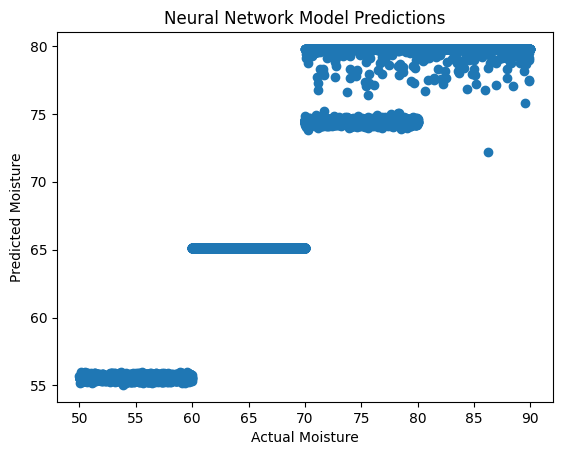

In [12]:

# Define the model
model = Sequential()
model.add(Dense(256, input_dim=X_train_scaled.shape[1], activation='relu'))  # Increase number of neurons in the first layer
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))  # Added another hidden layer
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=150, batch_size=32, validation_split=0.2)

# Evaluate the model
predictions = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Optionally plot predictions vs. actual values
plt.figure()
plt.scatter(y_test, predictions)
plt.xlabel("Actual Moisture")
plt.ylabel("Predicted Moisture")
plt.title("Neural Network Model Predictions")
plt.show()
